<a href="https://colab.research.google.com/github/VivekRupapara146/Grownited-Internship/blob/Data-Cleaning-Project/Data_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Cleaning and Visualization Project

Database link : https://drive.google.com/file/d/17Q9zLpzu4Hs19GWlyTFQ4cIvQmYoZB-R/view?usp=sharing

# Project Overview


## 📊 Retail Sales Data Cleaning and Preprocessing Project

## Executive Summary
This project demonstrates a comprehensive approach to transforming a raw, intentionally messy retail sales dataset into a clean, analysis-ready format through systematic data cleaning and preprocessing. Unlike conventional approaches that prioritize completeness through aggressive imputation, this project emphasizes **data integrity, logical consistency, and transparent decision-making**—principles fundamental to real-world data engineering.

The cleaning process was executed incrementally with intermediate checkpoints, guided by business logic, mathematical validation, and dependency awareness. The final dataset maintains reproducibility, preserves uncertainty where appropriate, and documents all transformations explicitly.

---

## 1. Project Overview

### 1.1 Dataset Characteristics
- **Total Records:** 12,575 retail transactions  
- **Original Columns:** 11 fields capturing customer purchase information  
- **Data Scope:** Transactions from a limited customer base across multiple product categories  
- **Data Quality:** Intentionally introduced inconsistencies, missing values, and logical errors simulating real-world messy data  

### 1.2 Project Objectives
- ✅ **Ensure Data Correctness:** Validate and correct erroneous values based on business logic  
- ✅ **Maintain Logical Consistency:** Preserve mathematical relationships between dependent fields  
- ✅ **Practice Transparent Decision-Making:** Document every cleaning decision with clear rationale  
- ✅ **Apply Real-World Best Practices:** Follow industry-standard data quality principles  
- ✅ **Preserve Data Integrity:** Avoid introducing bias through unfounded imputation  

**Key Principle:**  
Rather than aiming for zero missing values, focus on data correctness, logical consistency, and transparent decision-making. Restraint in imputation preserves data trust.

---

## 2. Methodology and Guiding Principles

### 2.1 Strategic Approach
The cleaning process was performed incrementally with checkpoints saved at each stage:

- **Reproducibility:** Steps can be revisited without restarting  
- **Rollback Capability:** Errors corrected by reverting to previous versions  
- **Audit Trail:** Complete documentation of transformations  
- **Version Control:** Three intermediate exports (v1, v2, v3) for comparison  

### 2.2 Core Principles

| Principle | Implementation |
|---------|----------------|
| Validate Before Filling | Verify mathematical/logical relationships before imputing |
| Evidence-Based Inference | Infer only when assumptions are provably safe |
| Preserve Uncertainty | Retain missing values when inference introduces bias |
| Explicit Documentation | Record rationale for all decisions, including non-actions |
| Dependency Awareness | Consider column interdependencies during cleaning |
| Transparency Through Flagging | Mark inferred values to distinguish from original data |

---

## 3. Detailed Cleaning Process

### Phase 1: Loading and Initial Exploration
**Actions Performed:**
- Data Import: Loaded raw CSV into pandas DataFrame  
- Structural Analysis: Used `.shape()`, `.head()`, `.tail()`, `.info()`, `.describe()`  
- Missing Value Assessment: Computed column-wise null counts with `.isnull().sum()`  

**Outcome:**  
Comprehensive understanding of data quality challenges and cleaning priorities.

---

### Phase 2: Structural Cleanup

#### Column Name Standardization
- Removed extra spaces, converted to lowercase, replaced spaces with underscores  
- Example: `"Price Per Unit"` → `price_per_unit`  
- **Rationale:** Improves code readability, prevents errors, follows Python conventions  

#### Granularity Verification
- Confirmed `transaction_id` uniqueness (transaction-level granularity)  
- Validated repeated `customer_id` values as expected  

#### Duplicate and Unusable Row Removal
- **Duplicate Check:** No exact duplicates found  
- **Unusable Rows:** Dropped records where `discount_applied`, `price_per_unit`, **and** `item` were all missing  
- **Rationale:** Such records lack core transactional details for meaningful analysis  

---

### Phase 3: Categorical Field Validation

**Fields Analyzed:** `category`, `payment_method`, `item`

#### Clean Categorical Fields
- `category` and `payment_method` examined using `.value_counts()`  
- Found low cardinality, complete data, consistent formatting  
- **Decision:** No corrective action required  

#### Item Field Reconstruction
**Challenge:** Missing values in `item` column  

**Methodology:**
- Pattern Investigation: Analyzed relationships between `item`, `category`, `price_per_unit`  
- Reference Table: Built lookup `(category, price_per_unit) → item`  
- Safe Mapping: Retained one-to-one mappings only  
- Controlled Imputation: Filled missing items only for validated unique relationships  
- Transparency: Added `item_was_missing` indicator  

**What Was NOT Done:**
- No artificial item names created  
- No probabilistic imputation  
- Ambiguous cases intentionally left missing  

**Outcome:** Partial completion with documented ambiguity preservation.

---

### Phase 4: Numerical Field Reconstruction

#### Step 4.1: Price Per Unit
**Reconstruction Logic:**
```
IF (total_spent known) AND (quantity known) AND (discount = False OR missing):
price_per_unit = total_spent / quantity
FLAG in price_reconstructed
ELSE:
LEAVE missing
```

**Validation Rules:**
- Only for non-discounted transactions  
- Required valid `total_spent` and positive `quantity`  
- Discounted transactions excluded  

---

#### Step 4.2: Total Spent (Two-Stage Approach)

**Stage 1: Mathematical Inference**
```
IF (price_per_unit known) AND (quantity known) AND (discount = False):
total_spent = price_per_unit × quantity
FLAG in total_spent_inferred
```

**Stage 2: Statistical Estimation**
- Computed **median** spending per `(customer_id, category)`  
- Applied only when sufficient history existed  
- Flagged with `total_spent_estimated`  
- Median chosen over mean to reduce outlier influence  

---

#### Step 4.3: Discount Applied
**Inference Strategy:**
- Defined tolerance `TOL` for floating-point comparison  

```
IF |price_per_unit × quantity − total_spent| ≤ TOL:
discount_applied = False
FLAG in discount_inferred
ELSE IF discount_applied = True:
PRESERVE
ELSE:
LEAVE missing
```

**Key Decisions:**
- Never overwrote existing `True` values  
- Converted to nullable boolean type  

---

#### Step 4.4: Quantity (Intentional Non-Imputation)
**Validation:**
- ✅ No zero, negative, or fractional quantities  
- ✅ All existing quantities valid integers  

**Reconstruction Analysis:**
- Evaluated `quantity = total_spent / price_per_unit`  
- **Finding:** No rows qualified for safe inference  

**Decision:** No imputation performed  

**Rationale:**  
Quantity is a core transactional field; guessing introduces significant bias.

---

### Phase 5: Temporal Data Handling
- Converted `transaction_date` to `datetime64[ns]`  
- Invalid dates coerced to `NaT` using `errors='coerce'`  

---

### Phase 6: Version Control
**Intermediate Checkpoints:**
- `v1`: After price reconstruction and initial item inference  
- `v2`: After discount inference and median estimations  
- `v3`: Final cleaned dataset with type conversions  

---

## 4. Final Data Quality Assessment

### 4.1 Remaining Missing Values

| Column | Justification |
|------|---------------|
| quantity | Core field; not inferable without guessing |
| total_spent | Depends on quantity |
| price_per_unit | Discounted or ambiguous cases |
| item | Non-unique category–price mappings |
| discount_applied | Insufficient evidence to classify |

**Key Insight:**  
Missing values were preserved where uncertainty could not be resolved safely.

---

### 4.2 Transparency Flags Created

| Flag Column | Purpose |
|------------|---------|
| price_reconstructed | Marks calculated prices |
| item_was_missing | Records inferred items |
| discount_inferred | Identifies inferred discounts |
| total_spent_inferred | Marks mathematical totals |
| total_spent_estimated | Identifies median-based estimates |

---

### 4.3 Quality Improvements Achieved
- ✅ Logically consistent  
- ✅ Semantically typed  
- ✅ Transparent inference  
- ✅ Dependency-aware  
- ✅ Analysis-ready  
- ✅ Fully auditable  

---

## 5. Key Learnings and Best Practices

1. **Not All Missing Data Should Be Filled**  
2. **Mathematical Relationships Are Powerful**  
3. **Transparency Through Flagging**  
4. **Dependency-Aware Cleaning**  
5. **Documentation of Non-Actions**

---

## 6. Technical Skills Demonstrated

### Python & Pandas
- Data import/export  
- EDA and profiling  
- Nullable dtype management  
- Conditional logic and aggregation  
- Joins, merges, and lookups  

### Data Engineering Principles
- Incremental processing  
- Reproducibility and audit trails  
- Business-rule enforcement  

### Analytical Thinking
- Root cause analysis  
- Trade-off evaluation  
- Risk-aware inference  

---

## 7. Final Deliverables

### 7.1 Cleaned Datasets
- `retail_sales_intermediate_v1.csv`  
- `retail_sales_intermediate_v2.csv`  
- `retail_sales_cleaned.csv`  

### 7.2 Dataset Characteristics
- ✅ Logically consistent  
- ✅ Semantically typed  
- ✅ Transparent assumptions  
- ✅ Analysis-ready  

---

## 8. Conclusion
This project demonstrates professional-grade data cleaning practices that prioritize **data integrity, logical consistency, and analytical reliability** over superficial completeness.

By applying evidence-based inference, dependency-aware processing, incremental checkpointing, and transparent flagging, the final dataset provides a trustworthy foundation for business analysis without introducing hidden bias.

**Core Achievement:**  
Transformed intentionally messy retail data into a clean, analysis-ready format while maintaining full transparency in data quality trade-offs—an essential skill for production data pipelines and analytical decision-making.


# imports

In [623]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Data Cleaning

###Loading and initial exploration
- Imported the raw retail sales data from CSV into a pandas DataFrame for further cleaning and analysis.

- Checked the overall size and structure of the dataset using `.shape`, `.head()`, and `.tail()` to understand row/column counts and sample records.

- Used `.info()` and `.describe()` to review data types, numerical distributions, and potential issues such as missing values or unexpected ranges.

- Computed column-wise null counts with `.isnull()` , `.sum()`  to get an initial overview of data completeness.

In [624]:
df= pd.read_csv("/content/retail_store_sales.csv")

In [625]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [626]:
print(df.shape)

(12575, 11)


In [627]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [628]:
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [629]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [630]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [631]:
print(df.describe(include = "number").T)
print()
print(df.describe(include = "O").T )
print()
# print(df.describe(include = "all").T)

                  count        mean        std  min   25%    50%    75%    max
Price Per Unit  11966.0   23.365912  10.743519  5.0  14.0   23.0   33.5   41.0
Quantity        11971.0    5.536380   2.857883  1.0   3.0    6.0    8.0   10.0
Total Spent     11971.0  129.652577  94.750697  5.0  51.0  108.5  192.0  410.0

                  count unique                            top  freq
Transaction ID    12575  12575                    TXN_2407494     1
Customer ID       12575     25                        CUST_05   544
Category          12575      8  Electric household essentials  1591
Item              11362    200                     Item_2_BEV   126
Payment Method    12575      3                           Cash  4310
Location          12575      2                         Online  6354
Transaction Date  12575   1114                     2022-05-30    26
Discount Applied   8376      2                           True  4219



###Standardizing column names
- Removed extra spaces, converted names to lowercase, and replaced spaces with underscores to create consistent, analysis-friendly column names.

- Ensured all columns follow a uniform naming convention, which simplifies querying, feature engineering, and reuse of the dataset in other notebooks.

- Verified the updated schema with `.info()` and summary statistics to confirm that only labels changed, not the underlying data.

In [632]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [633]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

In [634]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='object')

###Duplicate check and dropping unusable rows
- Checked for fully duplicated rows using `.duplicated()` , `.sum()` to confirm there were no exact duplicate records in the dataset.​

- Dropped rows where `discount_applied` , `price_per_unit` and `item` were all missing, because such records lack core transactional details and cannot support meaningful analysis.​

- Recomputed missing value counts to validate that only non‑informative rows were removed and that data quality improved without significant information loss.

In [635]:
df.duplicated().sum()
# no duplicates found

np.int64(0)

droping columns:
- where `discount_applied` , `price_per_unit` and `item` all are null because respective data can not be used for any analysis.

In [636]:
df.dropna(
    subset = ["discount_applied", "price_per_unit", "item"],
    how = "all",
    inplace = True
    )

In [637]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,1008
price_per_unit,404
quantity,604
total_spent,604
payment_method,0
location,0
transaction_date,0


###Column-wise inspection: category and payment method
- Examined the distribution of category using `.value_counts()` to confirm all entries were valid and that there were no missing or inconsistent category labels.​

- Checked `payment_method` values to ensure there were no unexpected codes or nulls, confirming that this field is clean and ready for downstream analysis (e.g., payment mix or preferences).​

- Decided that neither `category` nor `payment_method` required corrective cleaning, since both columns showed complete and consistent data.

In [638]:
df["category"].value_counts()

,count
category,
Furniture,1571
Electric household essentials,1563
Food,1562
Milk Products,1554
Beverages,1546
Butchers,1545
Computers and electric accessories,1529
Patisserie,1500


In [639]:
df["payment_method"].value_counts()

,count
payment_method,
Cash,4246
Credit Card,4063
Digital Wallet,4061


###Investigating and reconstructing item and price_per_unit
- Identified missing values in the `item` column and investigated how item information relates to `category` , `price_per_unit` , `quantity` , and `total_spent` .

- Reconstructed `price_per_unit` where possible by using the relationship `price_per_unit` = `total_spent` / `quantity` for rows with valid *totals*, *positive quantity*, and no *discount* applied.

- Tracked all reconstructed prices in a *helper flag* column `price_reconstructed` to maintain transparency about which records were inferred versus originally present.​

In [640]:
df["item"].value_counts()

,count
item,
Item_2_BEV,126
Item_25_FUR,113
Item_11_FUR,110
Item_16_MILK,109
Item_1_MILK,109
...,...
Item_5_BEV,7
Item_13_BEV,7
Item_13_FUR,7


In [641]:
df['price_per_unit'].isnull().sum()

np.int64(404)

In [642]:
df['price_reconstructed'] = False

mask = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna() &
    (df['quantity'] > 0) &
    (df['discount_applied'] == False)
)

df.loc[mask, 'price_per_unit'] = (
    df.loc[mask, 'total_spent'] / df.loc[mask, 'quantity']
)

df.loc[mask, 'price_reconstructed'] = True


In [643]:
df['price_reconstructed'].value_counts()
#  186 values changed

,count
price_reconstructed,
False,12184
True,186


In [644]:
df['price_per_unit'].isnull().sum()

np.int64(218)

- These prices are empty because of one of the column used to calculate must be empty

###Inferring item names from category–price patterns
- Built a reference table of **unique item values** *grouped by* `category` and `price_per_unit` to identify stable mappings between *categories*, *prices* and *item names*.

- Filtered this reference to “safe” mappings where a given `category, price_per_unit` pair corresponds to exactly one item, reducing the risk of incorrect imputations.

- Merged these safe mappings back into the main DataFrame and filled missing item values with the inferred names, leaving ambiguous cases as missing.

- Added an `item_was_missing` flag to record which records originally lacked item information and to facilitate *auditing* or *sensitivity* checks later.​



In [645]:
# refrence table
item_ref = (
    df[df['item'].notna()]
    .groupby(['category', 'price_per_unit'])['item']
    .unique()
    .reset_index()
)
# keeping mappings where only one mapping exists

item_ref['item_count'] = item_ref['item'].apply(len)
safe_item_ref = item_ref[item_ref['item_count']==1]

# extract single line
safe_item_ref['inferred_item'] = safe_item_ref['item'].apply(lambda x: x[0])

safe_item_ref = safe_item_ref[['category', 'price_per_unit', 'inferred_item']]

In [646]:
item_ref

,category,price_per_unit,item,item_count
0,Beverages,5.0,[Item_1_BEV],1
1,Beverages,6.5,[Item_2_BEV],1
2,Beverages,8.0,[Item_3_BEV],1
3,Beverages,9.5,[Item_4_BEV],1
4,Beverages,11.0,[Item_5_BEV],1
...,...,...,...,...
195,Patisserie,35.0,[Item_21_PAT],1
196,Patisserie,36.5,[Item_22_PAT],1
197,Patisserie,38.0,[Item_23_PAT],1
198,Patisserie,39.5,[Item_24_PAT],1


In [647]:
# merge to df
df = df.merge(safe_item_ref, on=['category', 'price_per_unit'], how='left')
df

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,price_reconstructed,inferred_item
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,False,Item_10_PAT
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,False,Item_17_MILK
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,False,Item_12_BUT
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,False,Item_16_BEV
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,False,Item_6_FOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12365,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN,False,Item_23_PAT
12366,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,False,Item_2_BEV
12367,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN,False,Item_7_BUT
12368,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,False,Item_7_FUR


In [648]:
# # Fill missing vlaues
df['item'] = df['item'].fillna(df['inferred_item'])
df.drop(columns=['inferred_item'], inplace=True)
df['item_was_missing'] = df['item'].isna()

In [649]:
df['item_was_missing'].value_counts()

,count
item_was_missing,
False,12152
True,218


In [650]:
df['item'].isnull().sum()
# these values are still null because of multiple items with same price.

np.int64(218)

In [651]:
print("Shape:", df.shape)
print("Missing price_per_unit:", df['price_per_unit'].isna().sum())
print("Missing item:", df['item'].isna().sum())

Shape: (12370, 13)
Missing price_per_unit: 218
Missing item: 218


###Exporting intermediate cleaned versions
- Saved the partially cleaned dataset (with reconstructed prices and improved item information) to `retail_sales_intermediate_v1.csv` for versioning and backup.​

- This intermediate export allows rolling back or comparing different cleaning strategies without re-running the entire pipeline.

In [652]:
temp_path = "retail_sales_intermediate_v1.csv"
df.to_csv(temp_path, index = False)

###Inferring discount_applied where possible
- Identified rows with missing `discount_applied` but valid `price_per_unit` , `quantity` and `total_spent` to see if a discount logically occurred.

- Used a small tolerance `TOL` to compare `price_per_unit` * `quantity` with `total_spent`; when they matched within the threshold, the transaction was labeled as having no discount `False`.

- Recorded which discount flags were inferred in a helper column `discount_inferred` to preserve *visibility* into imputed values versus original entries.

In [653]:
TOL = 0.01

In [654]:
mask = (
    df['discount_applied'].isna() &
    df['price_per_unit'].notna() &
    df['quantity'].notna() &
    df['total_spent'].notna() &
    (df['quantity'] > 0) &
    (
        (df['price_per_unit'] * df['quantity'] - df['total_spent']).abs() < TOL
    )
)

In [655]:
df.loc[mask, 'discount_applied'] = False
df['discount_inferred'] = False
df.loc[mask, 'discount_inferred'] = True

###Estimating remaining total_spent via customer–category medians
- For rows where total_spent was still missing, computed the median spending per `customer_id` , `category` group using all available non‑null transactions.

- Merged these median values into the main DataFrame and used them to estimate `total_spent` where the group `median` was available, flagging these rows in `total_spent_estimated`.

- Chose the `median` instead of the `mean` to reduce the influence of extreme outliers and better represent typical spending behavior within each `customer–category` combination.

- Dropped the temporary `median_spent` column after imputation and exported another intermediate snapshot as `retail_sales_intermediate_v2.csv`.

In [656]:
df['total_spent_inferred'] = False

In [657]:
mask = (
    df['total_spent'].isna() &
    df['price_per_unit'].notna() &
    df['quantity'].notna() &
    (df['quantity'] > 0) &
    (df['discount_applied'] == False)
)

In [658]:
df.loc[mask, 'total_spent'] = (
    df.loc[mask, 'price_per_unit'] * df.loc[mask, 'quantity']
)

df.loc[mask, 'total_spent_inferred'] = True

In [659]:
# @title
df['total_spent'].isna().sum()

np.int64(604)

In [660]:
df['total_spent_inferred'].sum()

np.int64(0)

In [661]:
df['total_spent'].isnull().sum()

np.int64(604)

In [662]:
MIN_COUNT = 3 # for applying changes where there are min 3 itams bought in the category

# using groupby to set median in a new dataframe before changing directy to new dataframe
cust_spent = (
    df[df['total_spent'].notna()]
    .groupby(['customer_id','category'])['total_spent']
    .agg(
        median_spent = 'median',
        count = 'count'
    )
    .reset_index()
)
cust_spent

,customer_id,category,median_spent,count
0,CUST_01,Beverages,78.00,63
1,CUST_01,Butchers,107.50,63
2,CUST_01,Computers and electric accessories,82.50,71
3,CUST_01,Electric household essentials,124.00,52
4,CUST_01,Food,98.00,67
...,...,...,...,...
195,CUST_25,Electric household essentials,75.00,59
196,CUST_25,Food,133.50,46
197,CUST_25,Furniture,86.75,54
198,CUST_25,Milk Products,70.00,57


In [663]:
# cust_spent = cust_spent[
#     cust_spent['count'] >= MIN_COUNT
# ]
# cust_spent

# # since no values less then 3 no need for this step

In [664]:
# merging original dataframe
df = df.merge(
    cust_spent[['customer_id', 'category', 'median_spent']],
    on=['customer_id', 'category'],
    how='left'
)


In [665]:
df

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,price_reconstructed,item_was_missing,discount_inferred,total_spent_inferred,median_spent
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,False,False,False,False,96.00
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,False,False,False,False,87.25
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,False,False,False,False,94.25
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,False,False,True,False,104.50
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,False,False,False,False,119.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12365,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False,False,False,True,False,103.00
12366,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,False,False,False,False,130.50
12367,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False,False,False,True,False,105.00
12368,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,False,False,False,False,79.50


In [666]:
# applying where it is needed and checking where changes are applied
df['total_spent_estimated'] = False
mask = (
    df['total_spent'].isna() &
    df['median_spent'].notna()
)

df.loc[mask, 'total_spent'] = df.loc[mask, 'median_spent']
df.loc[mask, 'total_spent_estimated'] = True

In [667]:
df['total_spent_estimated'].sum()

np.int64(604)

In [668]:
df['total_spent'].isna().sum()

np.int64(0)

In [669]:
# dropp median spent
df.drop(columns=['median_spent'], inplace=True)

In [670]:
temp_path = "retail_sales_intermediate_v2.csv"
df.to_csv(temp_path, index = False)

###Final type conversions and validation
- Converted `transaction_date` to a proper datetime type using `pd.to_datetime` , enabling reliable time-based analysis such as `trends` , `seasonality` and `cohort tracking`.

- Cast `discount_applied` to a nullable `boolean` type to reflect its true logical nature and to simplify filtering and aggregations on this field.​

- Saved the fully cleaned dataset to `retail_sales_intermediate_v3.csv` and rechecked shape and null counts to confirm the dataset is consistent, well‑typed, and ready for analysis or visualization.

In [671]:
# Changing relevant DTypes
df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    errors='coerce'
)
df['discount_applied'] = (
    df['discount_applied']
    .astype('boolean')
)

In [672]:
df.shape

(12370, 16)

In [673]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,218
price_per_unit,218
quantity,604
total_spent,0
payment_method,0
location,0
transaction_date,0


###Additional cleaning for remaining null values

In [674]:
compare = (df['item'].isnull() & df['price_per_unit'])
compare.value_counts()

,count
False,12370


**Null Value Analysis and Decision**

- **Pattern Identified:** All null values in `price_per_unit` and `item` columns occur together in the same rows
  
- **Root Cause:** These missing values correspond exclusively to transactions where `discount_applied = True`
  
- **Why This Matters:**
  - Discounted transactions lack the original `price_per_unit` information
  - Without the original price, the exact `item` cannot be reliably determined
  - The discount amount/percentage is unknown, making reconstruction impossible
  
- **Mathematical Limitation:**
  - `price_per_unit` cannot be reverse-calculated from `total_spent` when discounts are applied
  - Formula `price_per_unit = total_spent / quantity` only works for non-discounted transactions
  - Unknown discount rate prevents accurate price recovery
  
- **Impact on Analysis:**
  - These records provide minimal statistical value without core pricing information
  - Including them could skew revenue, pricing, and product mix analyses
  - Missing price data prevents meaningful product-level insights
  
- **Decision Made:** Drop all rows where both `price_per_unit` and `item` are null
  
- **Justification:**
  - Preserves data integrity by removing incomplete transactional records
  - Prevents misleading statistical insights from partial data
  - Focuses analysis on complete, reliable transactions
  - Maintains logical consistency across the dataset
  
- **Data Quality Trade-off:**
  - Accept reduction in dataset size to maintain analytical reliability
  - Prefer accurate analysis on complete data over biased analysis on incomplete data

In [675]:
from re import sub
df.dropna(
    subset = ["price_per_unit", "item"],
    how = "all",
    inplace = True
)
print(df.shape)

(12152, 16)


**Quantity and Discount Applied - Circular Dependency Issue**

- **Circular Dependency Identified:** `quantity` and `discount_applied` have mutual dependence
  
- **Why These Cannot Be Inferred:**
  - To infer `quantity`, we need: `quantity = total_spent / price_per_unit`
  - This calculation is only valid when `discount_applied = False`
  - Without knowing `discount_applied` status, we cannot safely calculate `quantity`
  
- **Reverse Problem:**
  - To infer `discount_applied`, we need to verify: `price_per_unit × quantity ≈ total_spent`
  - Without knowing `quantity`, we cannot perform this mathematical validation
  - Missing `quantity` prevents us from determining if a discount was applied
  
- **Mathematical Constraint:**
  - Both fields depend on each other for validation
  - Neither can be reliably inferred without the other
  - Any assumption(based on `item` or `category`) would introduce unverifiable bias
  
- **Impact on Data Quality:**
  - Records missing both fields lack fundamental transactional information
  - Cannot validate pricing logic or transaction integrity
  - Unusable for revenue analysis, sales metrics, or inventory calculations
  
- **Decision Made:** Drop all rows where both `quantity` and `discount_applied` are null
  
- **Justification:**
  - Eliminates records with irrecoverable core information
  - Prevents cascading errors from incorrect assumptions
  - Maintains mathematical consistency across remaining data
  - Avoids circular inference that could introduce systematic bias
  
- **Data Integrity Principle:**
  - Better to remove incomplete records than introduce unfounded values
  - Preserves reliability of remaining dataset for analysis
  - Acknowledges limitations rather than masking them with guesses

In [676]:
df.dropna(
    subset = ["quantity", "discount_applied"],
    how = "all",
    inplace = True
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11941 entries, 0 to 12369
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   transaction_id         11941 non-null  object        
 1   customer_id            11941 non-null  object        
 2   category               11941 non-null  object        
 3   item                   11941 non-null  object        
 4   price_per_unit         11941 non-null  float64       
 5   quantity               11548 non-null  float64       
 6   total_spent            11941 non-null  float64       
 7   payment_method         11941 non-null  object        
 8   location               11941 non-null  object        
 9   transaction_date       11941 non-null  datetime64[ns]
 10  discount_applied       11941 non-null  boolean       
 11  price_reconstructed    11941 non-null  bool          
 12  item_was_missing       11941 non-null  bool          
 13  discou

**Quantity Reconstruction - Safe Mathematical Inference**

- **Current State:**
  - Only `quantity` column has remaining null values
  - All other columns (`total_spent`, `price_per_unit`, `discount_applied`) are fully populated
  - This creates an opportunity for safe reconstruction
  
- **Reconstruction Formula:**
```
  quantity = total_spent / price_per_unit
```
  
- **Application Condition:**
  - Apply calculation **only** when `discount_applied = False`
  - Skip reconstruction for discounted transactions (discount invalidates the formula)
  
- **Safety Checks:**
  - Verify `total_spent` is not null
  - Verify `price_per_unit` is not null and greater than zero
  - Confirm `discount_applied = False` before applying formula
  
- **Implementation Logic:**
```
  IF (discount_applied = False) AND (total_spent is known) AND (price_per_unit > 0):
      quantity = total_spent / price_per_unit
  ELSE:
      LEAVE as null
```
  
- **Post-Calculation Validation:**
  - Round results to nearest integer (quantities must be whole numbers)
  - Verify calculated quantities are positive
  - Check for unrealistic values (e.g., extremely large quantities)
  
- **Transparency:**
  - Flag reconstructed quantities for audit trail
  - Distinguish calculated values from original data

In [677]:
mask = (df['discount_applied'] == False)

df.loc[mask, 'quantity'] = (
    df.loc[mask, 'total_spent'] / df.loc[mask, 'price_per_unit']
)

df['quantity_reconstructed'] = False
df.loc[mask, 'quantity_reconstructed'] = True

In [678]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,0
price_per_unit,0
quantity,200
total_spent,0
payment_method,0
location,0
transaction_date,0


- Now the empty values are because of `discount_applied` is `True`
- To fill these values we can do two things:
  1. Drop these rows
  2. Filling using statastics
      
      Find an average `discount value` based on comparing `actual_spent` and `total_spent` where `discount_applied` is `True`.

      Based on `avg discount` use it for filling rest values such that `quantity` stays `int`

- Although statistical estimation of quantities based on discount behavior was considered, it was not applied due to the assumption-heavy nature of discount mechanisms and the risk of introducing fabricated transactional volumes.
- We will not drop them and use them in visuaization somewhere

In [679]:
temp_path = "retail_sales_cleaned.csv"
df.to_csv(temp_path, index = False)

cleaned_dataset: https://drive.google.com/file/d/1-yjJBjUZgN-OIWrq8-jLXaDibXbATo2Q/view?usp=sharing

###Final inspection before visualization

In [680]:
# dropping flag colums
df.drop(columns = ['price_reconstructed' , 'item_was_missing','discount_inferred','total_spent_inferred',	'total_spent_estimated',	'quantity_reconstructed'],inplace = True)

In [681]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='object')

In [682]:
df.shape

(11941, 11)

In [683]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,0
price_per_unit,0
quantity,200
total_spent,0
payment_method,0
location,0
transaction_date,0


# Visualisation

In [684]:
df = pd.read_csv("retail_sales_cleaned.csv")

In [685]:
df

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,price_reconstructed,item_was_missing,discount_inferred,total_spent_inferred,total_spent_estimated,quantity_reconstructed
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,False,False,False,False,False,False
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,False,False,False,False,False,False
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,False,False,False,False,False,True
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,False,False,True,False,False,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11936,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False,False,False,True,False,False,True
11937,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,False,False,False,False,False,True
11938,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False,False,False,True,False,False,True
11939,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,False,False,False,False,False,False


###1️⃣ Revenue by Category (Bar Chart)

- Helps identify high-value categories regardless of quantity uncertainty.

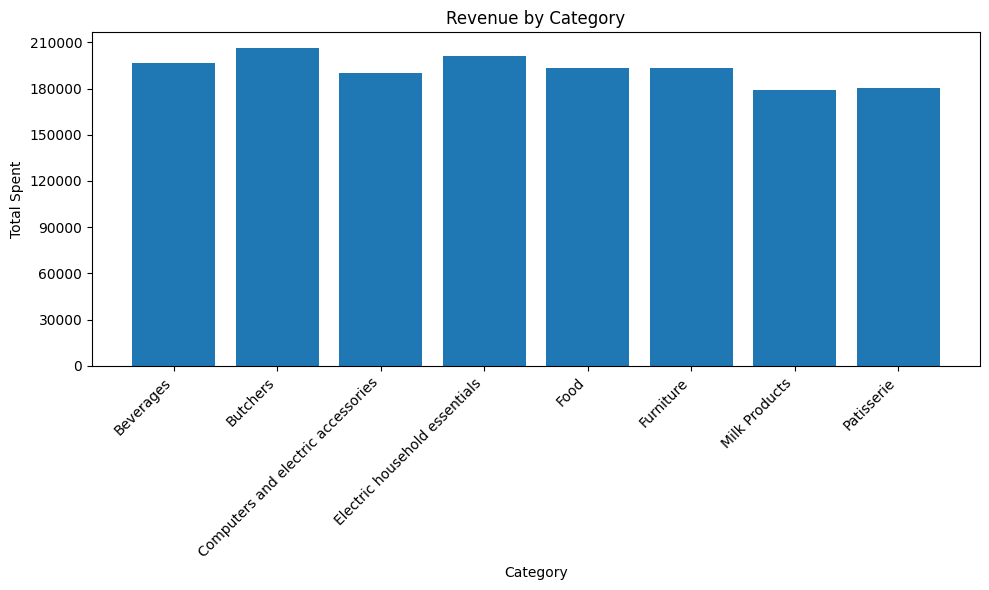

In [686]:
cat_group = df.groupby('category')['total_spent'].sum().reset_index()
plt.figure(figsize=(10, 6)) # Set a suitable figure size
plt.bar(cat_group['category'], height = cat_group['total_spent'])
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(np.arange(0,210001,30000))
plt.ylabel('Total Spent')
plt.xlabel('Category')
plt.title('Revenue by Category')
plt.tight_layout()
plt.show()

###📊Number of Transactions per Category(Bar Chart)

This chart helps you distinguish between:

- High-frequency, low-ticket categories

- Low-frequency, high-ticket categories

That distinction is critical in retail analysis.

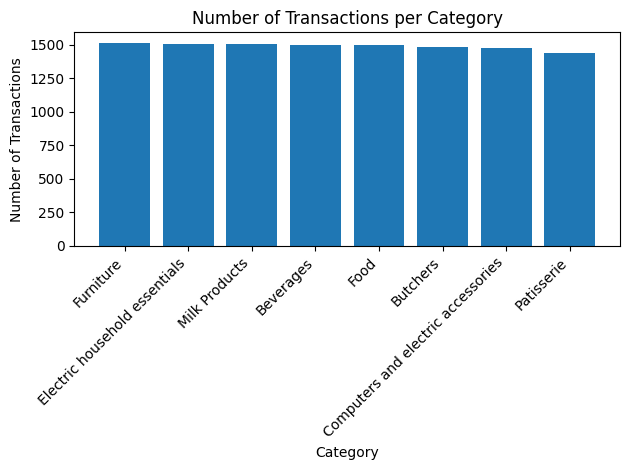

In [687]:
trans_by_cat = (
    df.groupby("category")["transaction_id"]
    .count()
    .sort_values(ascending=False)
)
plt.figure()
plt.bar(trans_by_cat.index, trans_by_cat.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.title("Number of Transactions per Category")
plt.tight_layout()
plt.show()

###📊 Monthly Revenue Trend (Line Plot)
- A line plot is ideal when the x-axis represents time and we want to understand trends, patterns, or changes.
- “How does total revenue change over time?”

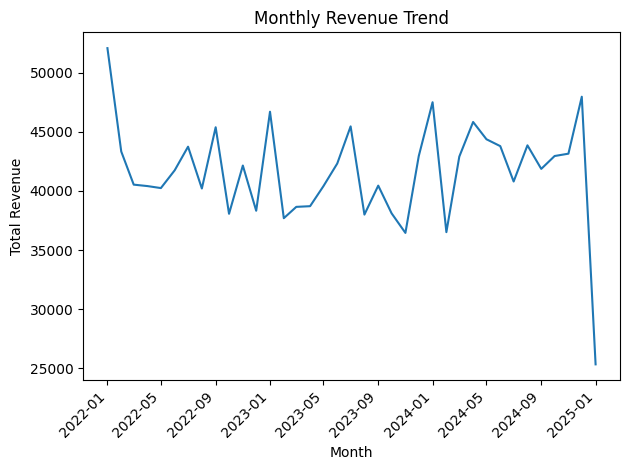

In [688]:
# Ensure transaction_date is datetime (safe check)
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Create a year-month column
df["year_month"] = df["transaction_date"].dt.to_period("M")

# Aggregate monthly revenue
monthly_revenue = (
    df.groupby("year_month")["total_spent"]
    .sum()
    .sort_index()
)

# Convert PeriodIndex to timestamp for plotting
monthly_revenue.index = monthly_revenue.index.to_timestamp()

# Plot
plt.figure()
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()